In [1]:
import sys
sys.path.append('..')

import copy
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import importlib.util
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
from src.losses import ReconstructionPIT_MSELoss, ReconstructionPIT_NMSELoss
from src.dataset import create_train_val_datasets
from src.utils import get_device
from config import (
    small_dataset_path,
    medium_dataset_path,
    large_dataset_path,
    huge_dataset_path,
    TRAIN_SIZE,
    SPLIT_STRATEGY,
    SPLIT_STRATEGY,
    SEED_TRAIN,
    SEED_VAL,
    SPLIT_SEED,
    MAX_K,
    CONSTANT_K,
    BATCH_SIZE,
    NB_OF_STEPS
)

In [2]:
device = get_device()
print(f"Using device : {device}") 

# run_name = Path("runs/run_20260722_171651") # SNR Weighting Run (Need to be on the branch "experiments/snr-weighting")
# run_name = Path("runs/run_20260722_171831") # Baseline Run  (Need to be on the branch "experiments/snr-weighting")
# run_name = Path("runs/run_20260722_171449") # Improved Model Run (Replaced LayerNorm by RMSNorm and FiLM) (Need to be on the branch "main" or "experiments/model_tuning")
run_name = Path("runs/run_20260803_105358") # Best Model (Improved Model + Normalized MSE DB Loss + Pet only at t= 0) (Need to be on the branch "db-normalized-loss")

run_path = "../" / run_name / "checkpoints"
model_structure_path = run_path / "model_structure.py"
ckpt_path = run_path / "best_checkpoint.pth"
dataset_path = medium_dataset_path

spec = importlib.util.spec_from_file_location(
    "dynamic_model", model_structure_path
)
dynamic_model_module = importlib.util.module_from_spec(spec)
sys.modules["dynamic_model"] = dynamic_model_module
spec.loader.exec_module(dynamic_model_module)

Using device : cuda:0


In [3]:
FlowSeparator = getattr(
    dynamic_model_module, "FlowSeparator"
)
model = FlowSeparator(max_k=MAX_K).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
number_of_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {number_of_parameters}")
model.eval()

Number of trainable parameters: 5342532


FlowSeparator(
  (mixture_encoder): ConvEncoder(
    (conv_encoder): Sequential(
      (conv_1): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=same)
      (layernorm_1): PermutedLayerNorm(
        (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (gelu_1): GELU(approximate='none')
      (dropout_1): Dropout(p=0.1, inplace=False)
      (conv_2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=same)
      (layernorm_2): PermutedLayerNorm(
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (gelu_2): GELU(approximate='none')
      (dropout_2): Dropout(p=0.1, inplace=False)
      (conv_3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
      (layernorm_3): PermutedLayerNorm(
        (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (gelu_3): GELU(approximate='none')
      (dropout_3): Dropout(p=0.1, inplace=False)
      (conv_4): Conv1d(128, 256, kernel_size=(5,), 

In [4]:
_, val_dataset = create_train_val_datasets(
        dataset_path,
        train_size=TRAIN_SIZE,
        max_K=MAX_K,
        constant_K=CONSTANT_K,
        max_samples_train=0,
        max_samples_val=10_000,
        noise_train=True,
        noise_val=True,
        deterministic_train=False,
        deterministic_val=True,
        split_seed=SPLIT_SEED,
        split_strategy=SPLIT_STRATEGY,
        seed_train=SEED_TRAIN,
        seed_val=SEED_VAL,
        return_params=True,
)

In [5]:
def build_initial_state(mixture, X_1, generator=None):
    B, L, _, _ = X_1.shape

    S_bar = mixture[:, None, :, :] / L
    S_bar = S_bar.repeat(1, L, 1, 1)

    Z = torch.randn(
        X_1.shape,
        device=X_1.device,
        dtype=X_1.dtype,
        generator=generator,
    )
    Z = Z - Z.mean(dim=1, keepdim=True)

    return S_bar + Z


dt = 1.0 / NB_OF_STEPS
generator = torch.Generator(device=device)
generator.manual_seed(0)

dataloader = DataLoader(
    val_dataset,
    batch_size=480,
    shuffle=False,
    num_workers=0
)

criterion = ReconstructionPIT_MSELoss(residual_weight=1.0)
nmse = ReconstructionPIT_NMSELoss()

T = 0.5 * (1 - np.cos(np.pi * np.linspace(0.0, 1.0, NB_OF_STEPS + 1)))

In [ ]:
# results_euler_simple_scheduler = []
# total_loss_euler_simple_scheduler = 0.0
# total_samples_euler_simple_scheduler = 0
# generator.manual_seed(0)

# dt_uniform = 1.0 / NB_OF_STEPS

# with torch.no_grad():
#     for mixture, X_1, K, params in tqdm(dataloader, desc="Evaluating using euler_simple_scheduler solver", leave=False):
#         mixture = mixture.to(device)
#         X_1 = X_1.to(device)
#         K = K.to(device)

#         B = X_1.shape[0]

#         X_t = build_initial_state(mixture, X_1, generator=generator)

#         for i in range(NB_OF_STEPS):
#             t_val = i * dt_uniform

#             t = torch.full(
#                 (B,),
#                 t_val,
#                 device=device,
#                 dtype=mixture.dtype,
#             )

#             v = model(X_t, t, mixture, K)

#             X_t = X_t + dt_uniform * v

#         X_hat = X_t

#         loss, source_loss, residual_loss = criterion(X_hat, X_1, reduction="none")
#         pred_sources = X_hat[:, :-1]
#         true_sources = X_1[:, :-1]
#         nmse_source, nmse_source_db = nmse(pred_sources, true_sources, reduction="none")
#         for b in range(B):
#             results_euler_simple_scheduler.append({
#                 "mixture": mixture[b].cpu().numpy(),
#                 "target": X_1[b].cpu().numpy(),
#                 "prediction": X_hat[b].cpu().numpy(),
#                 "loss": loss[b].item(),
#                 "source_loss": source_loss[b].item(),
#                 "residual_loss": residual_loss[b].item(),
                # "nmse_source": nmse_source[b].cpu().tolist(),
                # "nmse_source_db": nmse_source_db[b].cpu().tolist(),
#                 "snr": params["snr"][b].cpu().numpy(),
#             })
#         total_loss_euler_simple_scheduler += loss.sum().item()
#         total_samples_euler_simple_scheduler += B

# average_loss_euler_simple_scheduler = total_loss_euler_simple_scheduler / total_samples_euler_simple_scheduler
# print(f"Average loss using euler_simple_scheduler solver: {average_loss_euler_simple_scheduler:.6f}")

In [6]:
results_euler = []
total_loss_euler = 0.0
total_samples_euler = 0
generator.manual_seed(0)

with torch.no_grad():
    for mixture, X_1, K, params in tqdm(dataloader, desc="Evaluating using Euler solver", leave=False):
        mixture = mixture.to(device)
        X_1 = X_1.to(device)
        K = K.to(device)

        B = X_1.shape[0]

        X_t = build_initial_state(mixture, X_1, generator=generator)

        for i in range(NB_OF_STEPS):
            t_val = float(T[i])
            dt = float(T[i + 1] - T[i])

            t = torch.full(
                (B,),
                t_val,
                device=device,
                dtype=mixture.dtype,
            )

            v = model(X_t, t, mixture, K)

            X_t = X_t + dt * v

        X_hat = X_t

        loss, source_loss, residual_loss = criterion(X_hat, X_1, reduction="none")
        pred_sources = X_hat[:, :-1]
        true_sources = X_1[:, :-1]
        nmse_source, nmse_source_db = nmse(pred_sources, true_sources, reduction="none")
        for b in range(B):
            results_euler.append({
                "mixture": mixture[b].cpu().numpy(),
                "target": X_1[b].cpu().numpy(),
                "prediction": X_hat[b].cpu().numpy(),
                "loss": loss[b].item(),
                "source_loss": source_loss[b].item(),
                "residual_loss": residual_loss[b].item(),
                "nmse_source": nmse_source[b].cpu().tolist(),
                "nmse_source_db": nmse_source_db[b].cpu().tolist(),
                "snr": params["snr"][b].cpu().numpy(),
            })
        total_loss_euler += loss.sum().item()
        total_samples_euler += B

average_loss_euler = total_loss_euler / total_samples_euler
print(f"Average loss using Euler solver: {average_loss_euler:.6f}")

Evaluating using Euler solver:   0%|          | 0/21 [00:00<?, ?it/s]

Average loss using Euler solver: 0.410250


In [25]:
for idx, result in enumerate(results_euler):
    snrs = result["snr"]
    if snrs[0] < 20.0 and snrs[1] < 20.0:
        print("Mixture nber:", idx)

Mixture nber: 101
Mixture nber: 179
Mixture nber: 184
Mixture nber: 189
Mixture nber: 321
Mixture nber: 441
Mixture nber: 637
Mixture nber: 638
Mixture nber: 663
Mixture nber: 674
Mixture nber: 730
Mixture nber: 752
Mixture nber: 812
Mixture nber: 838
Mixture nber: 857
Mixture nber: 962
Mixture nber: 1198
Mixture nber: 1382
Mixture nber: 1453
Mixture nber: 1483
Mixture nber: 1604
Mixture nber: 1629
Mixture nber: 1742
Mixture nber: 1782
Mixture nber: 1784
Mixture nber: 1873
Mixture nber: 1919
Mixture nber: 2192
Mixture nber: 2313
Mixture nber: 2337
Mixture nber: 2371
Mixture nber: 2716
Mixture nber: 2753
Mixture nber: 2894
Mixture nber: 2921
Mixture nber: 3025
Mixture nber: 3284
Mixture nber: 3338
Mixture nber: 3353
Mixture nber: 3372
Mixture nber: 3573
Mixture nber: 3740
Mixture nber: 3813
Mixture nber: 3837
Mixture nber: 3866
Mixture nber: 4183
Mixture nber: 4250
Mixture nber: 4395
Mixture nber: 4477
Mixture nber: 4489
Mixture nber: 4503
Mixture nber: 4817
Mixture nber: 4980
Mixture n

In [ ]:
# results_heun = []
# total_loss_heun = 0.0
# total_samples_heun = 0
# generator.manual_seed(0)

# with torch.no_grad():
#     for mixture, X_1, K, params in tqdm(dataloader, desc="Evaluating using Heun solver", leave=False):

#         mixture = mixture.to(device)
#         X_1 = X_1.to(device)
#         K = K.to(device)

#         B = X_1.shape[0]

#         X_t = build_initial_state(
#             mixture,
#             X_1,
#             generator=generator
#         )

#         for i in range(NB_OF_STEPS):

#             t_val = float(T[i])
#             t_next_val = float(T[i + 1])
#             dt = t_next_val - t_val

#             t = torch.full(
#                 (B,),
#                 t_val,
#                 device=device,
#                 dtype=mixture.dtype,
#             )

#             t_next = torch.full(
#                 (B,),
#                 t_next_val,
#                 device=device,
#                 dtype=mixture.dtype,
#             )

#             v_t = model(
#                 X_t,
#                 t,
#                 mixture,
#                 K
#             )

#             X_pred = X_t + dt * v_t

#             v_next = model(
#                 X_pred,
#                 t_next,
#                 mixture,
#                 K
#             )

#             X_t = X_t + 0.5 * dt * (v_t + v_next)


#         X_hat = X_t

#         loss, source_loss, residual_loss = criterion(
#             X_hat,
#             X_1,
#             reduction="none"
#         )
#         pred_sources = X_hat[:, :-1]
#         true_sources = X_1[:, :-1]
#         nmse_source, nmse_source_db = nmse(pred_sources, true_sources, reduction="none")

#         for b in range(B):
#             results_heun.append({
#                 "mixture": mixture[b].cpu().numpy(),
#                 "target": X_1[b].cpu().numpy(),
#                 "prediction": X_hat[b].cpu().numpy(),
#                 "loss": loss[b].item(),
#                 "source_loss": source_loss[b].item(),
#                 "residual_loss": residual_loss[b].item(),
#                 "nmse_source": nmse_source[b].item(),
#                 "nmse_source_db": nmse_source_db[b].item(),
#                 "snr": params["snr"][b].cpu().numpy(),
#             })

#         total_loss_heun += loss.sum().item()
#         total_samples_heun += B


# average_loss_heun = total_loss_heun / total_samples_heun
# print(f"Average loss using Heun solver: {average_loss_heun:.6f}")

In [7]:
import pickle
from pathlib import Path

if not Path("results_euler.pkl").exists() or not Path("results_heun.pkl").exists():
    with open("results_euler.pkl", "wb") as f:
        pickle.dump(results_euler, f)
    # with open("results_heun.pkl", "wb") as f:
    #     pickle.dump(results_heun, f)
else:
    with open("results_euler.pkl", "rb") as f:
        results_euler = pickle.load(f)
    # with open("results_heun.pkl", "rb") as f:
    #     results_heun = pickle.load(f)

## Source reconstruction metrics by SNR

Each predicted source is first matched to a target source with Hungarian using the classic MSE. Its metrics are then assigned to the bin of the **true SNR of that target source**, not to a mixture SNR. The residual slot is not included here.

In [8]:
from scipy.optimize import linear_sum_assignment


def compute_source_metrics(results, solver):
    rows = []

    for sample_index, result in enumerate(results):
        target = np.asarray(result["target"])
        prediction = np.asarray(result["prediction"])
        snrs = np.asarray(result["snr"]).reshape(-1)
        n_sources = target.shape[0] - 1

        cost = np.mean(
            (prediction[:n_sources, None] - target[None, :n_sources]) ** 2,
            axis=(-1, -2),
        )
        predicted_slots, target_slots = linear_sum_assignment(cost)

        for predicted_slot, target_slot in zip(predicted_slots, target_slots):
            error = prediction[predicted_slot] - target[target_slot]
            error_energy = np.sum(error ** 2)
            source_energy = np.sum(target[target_slot] ** 2)
            nmse = error_energy / (source_energy + 1e-12)

            rows.append({
                "solver": solver,
                "sample": sample_index,
                "source": int(target_slot),
                "snr": float(snrs[target_slot]),
                "mse": float(np.mean(error ** 2)),
                "nmse": float(nmse),
                "nmse_db": float(10 * np.log10(nmse + 1e-12)),
            })

    return pd.DataFrame(rows)


source_metrics = pd.concat([
    # compute_source_metrics(results_euler_simple_scheduler, "Euler Simple Scheduler"),
    compute_source_metrics(results_euler, "Euler"),
    # compute_source_metrics(results_heun, "Heun"),
], ignore_index=True)

source_metrics.head()

,solver,sample,source,snr,mse,nmse,nmse_db
0,Euler,0,1,95.111641,0.146214,0.008275,-20.822086
1,Euler,0,0,37.033932,0.092344,0.034473,-14.625191
2,Euler,1,1,89.832275,0.264673,0.016792,-17.748859
3,Euler,1,0,21.005800,0.304132,0.352902,-4.523458
4,Euler,2,1,32.271339,0.075625,0.037180,-14.296963


In [9]:
snr_bin_edges = np.arange(10, 101, 10)
snr_bin_labels = [
    f"{left}-{right}"
    for left, right in zip(snr_bin_edges[:-1], snr_bin_edges[1:])
]

source_metrics["snr_bin"] = pd.cut(
    source_metrics["snr"],
    bins=snr_bin_edges,
    labels=snr_bin_labels,
    include_lowest=True,
)

snr_metrics = (
    source_metrics
    .groupby(["solver", "snr_bin"], observed=True)
    .agg(
        sources=("snr", "size"),
        mse=("mse", "mean"),
        nmse=("nmse", "mean"),
        nmse_db=("nmse_db", "mean"),
    )
    .reset_index()
)

snr_metrics

,solver,snr_bin,sources,mse,nmse,nmse_db
0,Euler,10-20,2186,0.094203,0.244066,-7.455922
1,Euler,20-30,2319,0.112534,0.095401,-11.540680
2,Euler,30-40,2199,0.138808,0.058389,-13.778643
3,Euler,40-50,2282,0.181684,0.045773,-15.297327
4,Euler,50-60,2204,0.206458,0.035024,-16.512249
5,Euler,60-70,2259,0.258493,0.031294,-17.543561
6,Euler,70-80,2150,0.256543,0.023604,-18.392047
7,Euler,80-90,2219,0.278532,0.019936,-19.163817
8,Euler,90-100,2182,0.258245,0.014692,-19.969366


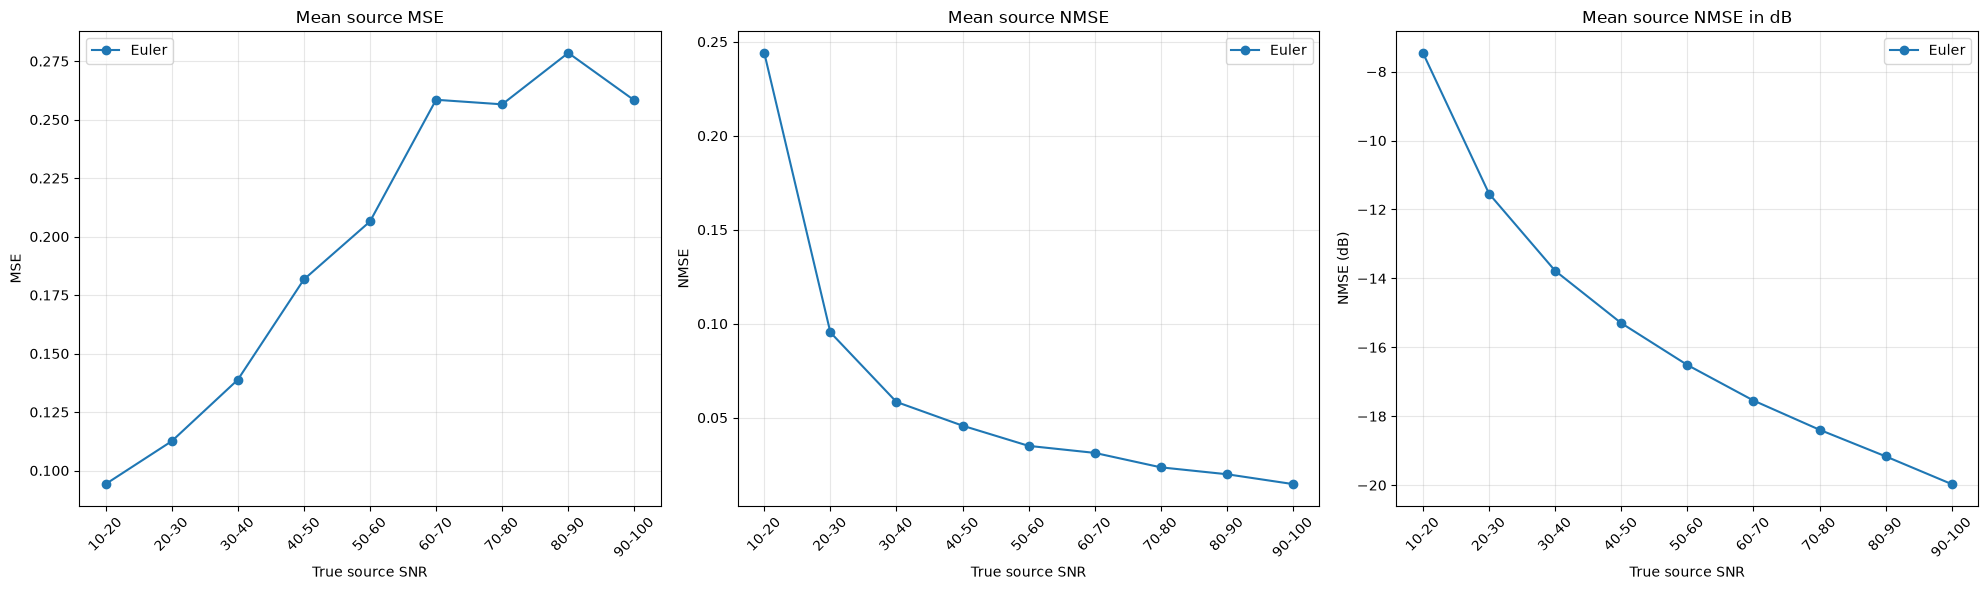

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plots = [
    ("mse", "MSE", "Mean source MSE"),
    ("nmse", "NMSE", "Mean source NMSE"),
    ("nmse_db", "NMSE (dB)", "Mean source NMSE in dB"),
]

for ax, (metric, ylabel, title) in zip(axes, plots):
    for solver, values in snr_metrics.groupby("solver", observed=True):
        ax.plot(
            values["snr_bin"].astype(str),
            values[metric],
            marker="o",
            label=solver,
        )

    ax.set_title(title)
    ax.set_xlabel("True source SNR")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.optimize import linear_sum_assignment

_result_sets = {
    name: values
    for name, values in {"Euler": results_euler}.items()
    if len(values) > 0
}
if not _result_sets:
    raise RuntimeError("Run the Euler or Heun evaluation cells first.")


def _align_prediction_with_target(prediction, target):
    """Align source slots with Hungarian; the residual stays last."""
    prediction = np.asarray(prediction)
    target = np.asarray(target)
    n_sources = target.shape[0] - 1

    cost = np.mean(
        (prediction[:n_sources, None] - target[None, :n_sources]) ** 2,
        axis=(-1, -2),
    )
    predicted_slots, target_slots = linear_sum_assignment(cost)

    aligned = np.empty_like(prediction)
    for predicted_slot, target_slot in zip(predicted_slots, target_slots):
        aligned[target_slot] = prediction[predicted_slot]
    aligned[-1] = prediction[-1]

    assignment = list(zip(predicted_slots.tolist(), target_slots.tolist()))
    return aligned, assignment


solver_widget = widgets.Dropdown(
    options=list(_result_sets),
    description="Results:",
)
element_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=len(_result_sets[solver_widget.value]) - 1,
    step=1,
    description="Element:",
    continuous_update=False,
    layout=widgets.Layout(width="650px"),
)
previous_button = widgets.Button(description="◀ Previous")
next_button = widgets.Button(description="Next ▶")

search_widget = widgets.Text(
    placeholder="Enter element index to search",
    description="Search:",
    layout=widgets.Layout(width="650px"),
)

def _on_search_change(change):
    try:
        search_idx = int(change["new"])
        max_idx = len(_result_sets[solver_widget.value]) - 1
        if 0 <= search_idx <= max_idx:
            element_widget.value = search_idx
        else:
            print(f"Index out of range [0, {max_idx}]")
    except ValueError:
        if change["new"]:  # Only show error if not empty
            print("Please enter a valid integer")

def _update_element_range(change):
    element_widget.max = len(_result_sets[change["new"]]) - 1
    element_widget.value = 0


def _previous(_):
    element_widget.value = max(element_widget.min, element_widget.value - 1)


def _next(_):
    element_widget.value = min(element_widget.max, element_widget.value + 1)


solver_widget.observe(_update_element_range, names="value")
previous_button.on_click(_previous)
next_button.on_click(_next)


def _plot_reconstruction(solver, element):
    result = _result_sets[solver][element]

    target = np.asarray(result["target"])
    prediction, assignment = _align_prediction_with_target(
        result["prediction"],
        target,
    )
    mixture = np.asarray(result["mixture"])

    n_slots, n_channels, n_frequency_bins = target.shape
    frequency_bins = np.arange(n_frequency_bins)
    source_snrs = np.asarray(result.get("snr", [])).reshape(-1)
    nmse_source = np.asarray(result.get("nmse_source", [])).reshape(-1)
    nmse_source_db = np.asarray(result.get("nmse_source_db", [])).reshape(-1)

    slot_names = [
        *[
            f"Source {source + 1} — SNR={source_snrs[source]:.2f}\nNMSE={nmse_source[source]:.6f} - NMSE(dB)={nmse_source_db[source]:.2f}"
            if source < len(source_snrs)
            else f"Source {source + 1} — SNR unavailable"
            for source in range(n_slots - 1)
        ],
        "Residual / noise",
    ]
    default_channel_names = ["A real", "A imag.", "E real", "E imag."]
    channel_names = [
        default_channel_names[channel]
        if channel < len(default_channel_names)
        else f"Channel {channel + 1}"
        for channel in range(n_channels)
    ]

    # Normalize mixture to shape (n_channels, n_frequency_bins)
    if mixture.ndim == 1:
        mixture = mixture[None, :]
    elif mixture.ndim > 2:
        mixture = mixture.reshape(mixture.shape[0], -1)

    if mixture.shape[0] != n_channels and mixture.shape[1] == n_channels:
        mixture = mixture.T

    if mixture.shape[0] != n_channels:
        raise ValueError(
            f"Expected mixture with {n_channels} channels, got shape {mixture.shape}"
        )

    mixture = mixture.reshape(n_channels, n_frequency_bins)

    n_rows = n_slots + 1
    fig, axes = plt.subplots(
        n_rows,
        n_channels,
        figsize=(4.5 * n_channels, 3.0 * n_rows),
        sharex=True,
        squeeze=False,
    )

    # Tailwind-inspired colors
    color_mixture = "#38d667"  # Indigo 500
    color_target = "#0800ff"   # Blue 500
    color_pred = "#ff8c00"     # Rose 500

    # Plot mixture on the first row
    for channel in range(n_channels):
        ax = axes[0, channel]
        ax.plot(
            frequency_bins,
            mixture[channel],
            label="Mixture",
            linewidth=2,
            color=color_mixture,
        )
        ax.set_title(f"Mixture — {channel_names[channel]}")
        ax.grid(alpha=0.2)
        if channel == 0:
            ax.legend()

    # Plot targets and predictions on subsequent rows
    for slot in range(n_slots):
        for channel in range(n_channels):
            ax = axes[slot + 1, channel]
            
            # Tracé de la cible (épais et transparent pour faire fond)
            ax.plot(
                frequency_bins,
                target[slot, channel],
                label="Target",
                linewidth=2.3,
                color=color_target,
                alpha=1.0,
            )
            # Tracé de la prédiction (fin et pointillé par dessus)
            ax.plot(
                frequency_bins,
                prediction[slot, channel],
                label="Prediction",
                linewidth=1.3,
                linestyle="--",
                color=color_pred,
                alpha=1.0,
            )
            
            ax.set_title(f"{slot_names[slot]} — {channel_names[channel]}")
            ax.grid(alpha=0.2)
            if slot == n_slots - 1:
                ax.set_xlabel("Frequency bin")
            if slot == 0 and channel == 0:
                ax.legend()

    stored_loss = float(result.get("loss", np.nan))
    stored_source_loss = float(result.get("source_loss", np.nan))
    stored_residual_loss = float(result.get("residual_loss", np.nan))
    
    fig.suptitle(
        f"{solver} — element {element}/{len(_result_sets[solver]) - 1}"
        f" — loss={stored_loss:.6g}"
        f" — source loss={stored_source_loss:.6g}"
        f" — residual loss={stored_residual_loss:.6g}"
        f" — predicted→target PIT: {assignment}",
        fontsize=14,
    )
    fig.tight_layout()
    plt.show()

search_widget.observe(_on_search_change, names="value")

controls = widgets.VBox([
    widgets.HBox([solver_widget, previous_button, next_button]),
    search_widget,
    element_widget,
])
plots = widgets.interactive_output(
    _plot_reconstruction,
    {"solver": solver_widget, "element": element_widget},
)
display(controls, plots)


Output()